# Weak-Value Measurement Strength Sweep on Hardware

## Motivation

The v6 simulation showed ΔH varies continuously with backward boundary coupling α_bwd —
from 0 (no post-selection) to 0.22 bits (projective) on the depth-2 HaPPY code. This is
the defining signature of weak measurement: partial information extraction scaling with
coupling strength.

This notebook reproduces that sweep on **real hardware data** from IBM Fez. The backward
boundary weight β in the DBCI kernel `p_dbci(h) ∝ p_fwd(h) × exp(-β × weight(h))` is
mathematically equivalent to the measurement strength parameter α. Varying β from 0
(forward-only) to large (strong post-selection) on existing data is a measurement strength
sweep without new QPU time.

## What we test

1. Does ΔH vary continuously with measurement strength on hardware? (v6 predicts yes)
2. Does the isotropy gap (HaPPY vs Steane vs Shor) emerge gradually or abruptly?
3. Per-stabilizer ΔH(β) curves — are these entanglement wedge weak values?

## Data

Existing hardware: `data/happy_553.npz`, `data/steane_713.npz`, `data/shor_913.npz`.
Zero QPU cost.

In [1]:
"""Cell 1: Imports, Drive Mount, and Setup"""

import numpy as np
from scipy import stats
from itertools import combinations
import matplotlib.pyplot as plt
import os

%matplotlib inline

SEED = 42
np.random.seed(SEED)

# Mount Google Drive and set output directory
from google.colab import drive
drive.mount('/content/drive')

OUTPUT_DIR = '.'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'OUTPUT_DIR = {OUTPUT_DIR}')
print('Imports OK')

In [2]:
"""Cell 2: Code Definitions — HaPPY, Steane, Shor"""

# --- HaPPY [[5,1,3]] ---
HAPPY_STABS = ["XZZXI", "IXZZX", "XIXZZ", "ZXIXZ"]
HAPPY_N = 5
HAPPY_ZL = "ZZZZZ"

def build_errors(n, paulis="XYZ"):
    """Build identity + all single-qubit Pauli errors."""
    errors = ["I" * n]
    for q in range(n):
        for p in paulis:
            e = list("I" * n)
            e[q] = p
            errors.append("".join(e))
    return errors

HAPPY_ERRORS = build_errors(5)  # 16 hypotheses

# --- Steane [[7,1,3]] ---
STEANE_STABS = ["IIIXXXX", "IXXIIXX", "XIXIXIX", "IIIZZZZ", "IZZIIZZ", "ZIZIZIZ"]
STEANE_N = 7
STEANE_ZL = "ZZZZZZZ"
STEANE_ERRORS = build_errors(7)  # 22 hypotheses

# --- Shor [[9,1,3]] ---
SHOR_STABS = [
    "ZZIIIIIII", "IZZIIIIII", "IIIZZIIII", "IIIIZZIII",
    "IIIIIIZZI", "IIIIIIIZZ", "XXXXXXIII", "IIIXXXXXX"
]
SHOR_N = 9
SHOR_ZL = "ZIIZIIIZI"

# Shor has Z-error degeneracy within blocks
def build_shor_errors():
    errors = ["I" * 9]
    for q in range(9):
        for p in "XY":
            e = list("I" * 9)
            e[q] = p
            errors.append("".join(e))
    # Z representatives: one per block
    for q in [0, 3, 6]:
        e = list("I" * 9)
        e[q] = "Z"
        errors.append("".join(e))
    return errors

SHOR_ERRORS = build_shor_errors()  # 22 hypotheses

print(f'HaPPY: {len(HAPPY_ERRORS)} hypotheses, {len(HAPPY_STABS)} stabilizers')
print(f'Steane: {len(STEANE_ERRORS)} hypotheses, {len(STEANE_STABS)} stabilizers')
print(f'Shor:   {len(SHOR_ERRORS)} hypotheses, {len(SHOR_STABS)} stabilizers')

HaPPY: 16 hypotheses, 4 stabilizers
Steane: 22 hypotheses, 6 stabilizers
Shor:   22 hypotheses, 8 stabilizers


In [4]:
"""Cell 3: Load Hardware Data"""

def make_labels(n):
    """Build error labels: I, X0, Y0, Z0, X1, ..."""
    labels = ['I']
    for q in range(n):
        for p in 'XYZ':
            labels.append(f'{p}{q}')
    return labels

def make_shor_labels():
    """Shor labels matching build_shor_errors(): XY on all 9, Z on reps 0,3,6."""
    labels = ['I']
    for q in range(9):
        for p in 'XY':
            labels.append(f'{p}{q}')
    for q in [0, 3, 6]:
        labels.append(f'Z{q}')
    return labels

def load_npz(npz_path, error_labels):
    """Load .npz with pub{i}_syn / pub{i}_out into L{state}_{label} dict."""
    raw = np.load(npz_path)
    circuit_labels = [f'L{s}_{l}' for s in [0, 1] for l in error_labels]
    hw = {}
    for i, clabel in enumerate(circuit_labels):
        hw[clabel] = {
            'syndrome': raw[f'pub{i}_syn'].astype(int),
            'data':     raw[f'pub{i}_out'].astype(int),
        }
    return hw, error_labels

# Input data lives in Colab root; output goes to Drive
DATA_DIR = '.'

happy_labels = make_labels(5)
steane_labels = make_labels(7)
shor_labels = make_shor_labels()

hw_happy, _ = load_npz(os.path.join(DATA_DIR, 'happy_553.npz'), happy_labels)
hw_steane, _ = load_npz(os.path.join(DATA_DIR, 'steane_713.npz'), steane_labels)
hw_shor, _ = load_npz(os.path.join(DATA_DIR, 'shor_913.npz'), shor_labels)

print(f'HaPPY:  {len(hw_happy)} circuits, {hw_happy["L0_I"]["syndrome"].shape[0]} shots')
print(f'Steane: {len(hw_steane)} circuits, {hw_steane["L0_I"]["syndrome"].shape[0]} shots')
print(f'Shor:   {len(hw_shor)} circuits, {hw_shor["L0_I"]["syndrome"].shape[0]} shots')

HaPPY:  32 circuits, 8192 shots
Steane: 44 circuits, 8192 shots
Shor:   44 circuits, 8192 shots


In [5]:
"""Cell 4: ΔH Computation Engine with Variable Measurement Strength β

The backward boundary prior controls measurement strength:
  p_no_err(β) = 1 / (1 + (n_hyp - 1) × exp(-β))

β = 0  → p_no_err = 1/n_hyp  → uniform prior → ΔH = 0 (no measurement)
β → ∞  → p_no_err → 1        → delta on identity → max ΔH (projective)
Intermediate β: weak measurement regime — partial info extraction.

This is mathematically equivalent to varying α_bwd in the v6 simulation.
"""

def entropy_bits(p):
    """Shannon entropy in bits."""
    p = np.asarray(p, dtype=np.float64)
    p = p[p > 0]
    return -np.sum(p * np.log2(p)) if len(p) > 0 else 0.0

def normalize_logits(logits):
    """Numerically stable softmax."""
    logits = np.asarray(logits, dtype=np.float64)
    logits = logits - np.max(logits)
    probs = np.exp(logits)
    Z = np.sum(probs)
    return probs / Z if Z > 1e-300 else np.ones_like(probs) / len(probs)

def compute_delta_H_at_beta(hw_data, error_labels, n_hyp, n_anc, beta,
                             stab_subset=None):
    """Compute mean ΔH at a single β value using 2-fold cross-validation.

    Uses the same empirical likelihood engine as isotropy_weighting.ipynb.

    Args:
        hw_data: dict keyed by 'L{state}_{label}'
        error_labels: list of error labels (I, X0, Y0, ...)
        n_hyp: number of error hypotheses
        n_anc: number of ancilla/stabilizer qubits
        beta: measurement strength parameter
        stab_subset: list of stabilizer indices to use (None = all)

    Returns:
        (mean_dH, sem_dH, all_dH_values)
    """
    n_sub = len(stab_subset) if stab_subset is not None else n_anc
    n_syn_space = 2 ** n_sub
    powers = 2 ** np.arange(n_sub - 1, -1, -1)

    # Build prior at this β
    p_no_err = 1.0 / (1.0 + (n_hyp - 1) * np.exp(-beta))
    log_prior = np.zeros(n_hyp)
    log_prior[0] = np.log(max(p_no_err, 1e-10))
    log_prior[1:] = np.log(max((1 - p_no_err) / (n_hyp - 1), 1e-10))

    log_uniform = np.zeros(n_hyp)  # forward-only reference

    all_dH = []

    for state in ['0', '1']:
        # Collect data for this logical state
        state_data = {}
        for idx, lbl in enumerate(error_labels):
            key = f'L{state}_{lbl}'
            if key in hw_data:
                syn = hw_data[key]['syndrome']
                if stab_subset is not None:
                    syn = syn[:, stab_subset]
                state_data[idx] = syn

        if not state_data:
            continue

        n_shots = len(list(state_data.values())[0])
        mid = n_shots // 2

        # 2-fold cross-validation
        for test_sl, train_sl in [(slice(0, mid), slice(mid, None)),
                                   (slice(mid, None), slice(0, mid))]:
            # Build empirical likelihood from training data
            log_lik = np.full((n_hyp, n_syn_space), np.log(1.0 / n_syn_space))

            for h in state_data:
                train_syn = state_data[h][train_sl]
                keys = (train_syn * powers).sum(axis=1).astype(int)
                counts = np.zeros(n_syn_space)
                for k in keys:
                    counts[k] += 1
                dist = (counts + 1) / (counts.sum() + n_syn_space)  # Laplace
                log_lik[h] = np.log(dist)

            # Evaluate ΔH on test data
            for h in state_data:
                test_syn = state_data[h][test_sl]
                test_keys = (test_syn * powers).sum(axis=1).astype(int)

                for sk in test_keys:
                    p_fwd = normalize_logits(log_lik[:, sk] + log_uniform)
                    p_dbci = normalize_logits(log_lik[:, sk] + log_prior)
                    dH = entropy_bits(p_fwd) - entropy_bits(p_dbci)
                    all_dH.append(dH)

    all_dH = np.array(all_dH)
    return np.mean(all_dH), np.std(all_dH) / np.sqrt(len(all_dH)), all_dH


def sweep_beta(hw_data, error_labels, n_hyp, n_anc, code_name,
               beta_values=None, stab_subset=None):
    """Sweep β and compute ΔH at each value."""
    if beta_values is None:
        beta_values = np.array([0, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0,
                                 6.0, 8.0, 10.0, 15.0, 20.0])

    means, sems = [], []
    for beta in beta_values:
        m, s, _ = compute_delta_H_at_beta(hw_data, error_labels, n_hyp, n_anc,
                                           beta, stab_subset)
        means.append(m)
        sems.append(s)

    means, sems = np.array(means), np.array(sems)
    stab_str = f'stabs={stab_subset}' if stab_subset is not None else 'all stabs'
    print(f'  {code_name} ({stab_str}): ΔH range [{means.min():.4f}, {means.max():.4f}] bits')
    return beta_values, means, sems

print('ΔH sweep engine defined.')

ΔH sweep engine defined.


Running global ΔH(β) sweep (all stabilizers)...

  HaPPY (all stabs): ΔH range [0.0000, 3.4442] bits
  Steane (all stabs): ΔH range [0.0000, 4.4220] bits
  Shor (all stabs): ΔH range [0.0000, 4.1902] bits

     β |     HaPPY ΔH |    Steane ΔH |      Shor ΔH
----------------------------------------------------
  0.00 |       0.0000 |       0.0000 |       0.0000
  0.25 |       0.0022 |       0.0021 |       0.0003
  0.50 |       0.0094 |       0.0102 |       0.0061
  1.00 |       0.0448 |       0.0554 |       0.0446
  1.50 |       0.1226 |       0.1647 |       0.1425
  2.00 |       0.2631 |       0.3741 |       0.3323
  3.00 |       0.7971 |       1.1843 |       1.0678
  4.00 |       1.6097 |       2.3354 |       2.1246
  6.00 |       2.9320 |       3.9099 |       3.6534
  8.00 |       3.3457 |       4.3288 |       4.0900
 10.00 |       3.4274 |       4.4065 |       4.1733
 15.00 |       3.4441 |       4.4219 |       4.1901
 20.00 |       3.4442 |       4.4220 |       4.1902


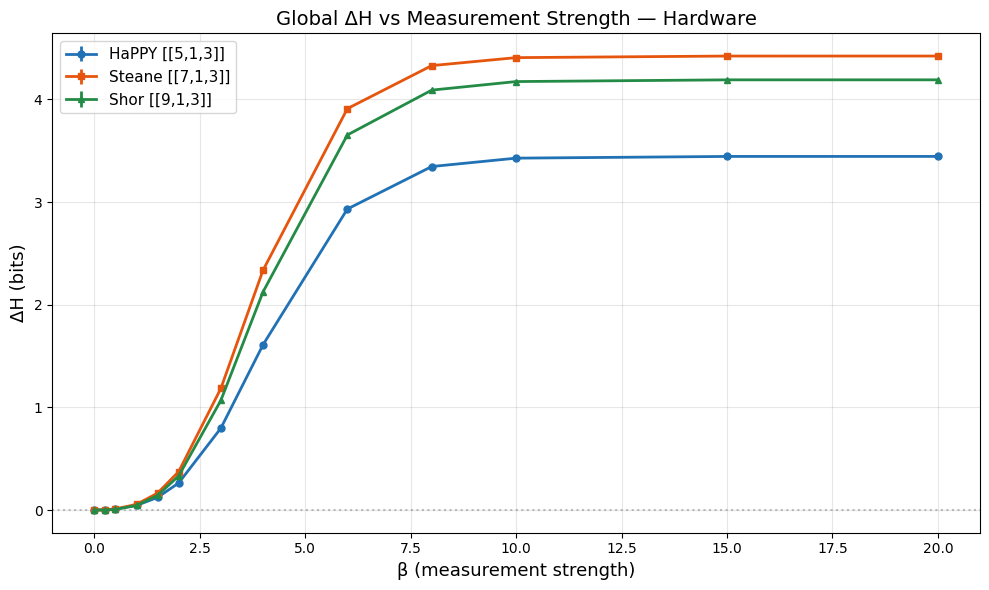

In [6]:
"""Cell 5: Global ΔH(β) Sweep — All Three Codes

Question 1: Does ΔH vary continuously with measurement strength on hardware?
v6 simulation predicts yes. This is the defining weak-measurement signature.
"""

print('Running global ΔH(β) sweep (all stabilizers)...\n')

beta_h, dH_h, sem_h = sweep_beta(hw_happy, happy_labels, len(HAPPY_ERRORS),
                                   len(HAPPY_STABS), 'HaPPY')
beta_s, dH_s, sem_s = sweep_beta(hw_steane, steane_labels, len(STEANE_ERRORS),
                                   len(STEANE_STABS), 'Steane')
beta_r, dH_r, sem_r = sweep_beta(hw_shor, shor_labels, len(SHOR_ERRORS),
                                   len(SHOR_STABS), 'Shor')

# Print table
print(f'\n{"β":>6} | {"HaPPY ΔH":>12} | {"Steane ΔH":>12} | {"Shor ΔH":>12}')
print('-' * 52)
for i, b in enumerate(beta_h):
    print(f'{b:6.2f} | {dH_h[i]:12.4f} | {dH_s[i]:12.4f} | {dH_r[i]:12.4f}')

# Plot and save
fig, ax = plt.subplots(figsize=(10, 6))
ax.errorbar(beta_h, dH_h, yerr=sem_h, fmt='o-', lw=2, ms=5, label='HaPPY [[5,1,3]]', color='#2171b5')
ax.errorbar(beta_s, dH_s, yerr=sem_s, fmt='s-', lw=2, ms=5, label='Steane [[7,1,3]]', color='#e6550d')
ax.errorbar(beta_r, dH_r, yerr=sem_r, fmt='^-', lw=2, ms=5, label='Shor [[9,1,3]]', color='#238b45')
ax.set_xlabel('β (measurement strength)', fontsize=13)
ax.set_ylabel('ΔH (bits)', fontsize=13)
ax.set_title('Global ΔH vs Measurement Strength — Hardware', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', ls=':', alpha=0.5)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'strength_sweep_global.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [7]:
"""Cell 6: Per-Stabilizer ΔH(β) Sweep

Question 3: Are per-stabilizer ΔH(β) curves entanglement wedge weak values?

On the HaPPY code, different stabilizers access different entanglement wedges.
If ΔH(β) curves separate by stabilizer, each curve is the weak value of the
backward boundary measured through a different wedge subregion.

On Steane (non-holographic), all curves should overlap (isotropic).
"""

print('Running per-stabilizer ΔH(β) sweep...\n')

# Use a coarser β grid for per-stabilizer (faster)
beta_per_stab = np.array([0, 0.5, 1.0, 2.0, 3.0, 5.0, 8.0, 12.0, 20.0])

# HaPPY per-stabilizer
print('HaPPY [[5,1,3]]:')
happy_per_stab = {}
for si in range(len(HAPPY_STABS)):
    bv, mv, sv = sweep_beta(hw_happy, happy_labels, len(HAPPY_ERRORS),
                             len(HAPPY_STABS), f'  S{si} {HAPPY_STABS[si]}',
                             beta_values=beta_per_stab, stab_subset=[si])
    happy_per_stab[si] = (bv, mv, sv)

# Steane per-stabilizer
print('\nSteane [[7,1,3]]:')
steane_per_stab = {}
for si in range(len(STEANE_STABS)):
    bv, mv, sv = sweep_beta(hw_steane, steane_labels, len(STEANE_ERRORS),
                             len(STEANE_STABS), f'  S{si} {STEANE_STABS[si]}',
                             beta_values=beta_per_stab, stab_subset=[si])
    steane_per_stab[si] = (bv, mv, sv)

# Shor per-stabilizer
print('\nShor [[9,1,3]]:')
shor_per_stab = {}
for si in range(len(SHOR_STABS)):
    bv, mv, sv = sweep_beta(hw_shor, shor_labels, len(SHOR_ERRORS),
                             len(SHOR_STABS), f'  S{si} {SHOR_STABS[si]}',
                             beta_values=beta_per_stab, stab_subset=[si])
    shor_per_stab[si] = (bv, mv, sv)

print('\nPer-stabilizer sweep complete.')

Running per-stabilizer ΔH(β) sweep...

HaPPY [[5,1,3]]:
    S0 XZZXI (stabs=[0]): ΔH range [0.0000, 3.7518] bits
    S1 IXZZX (stabs=[1]): ΔH range [-0.0000, 3.9010] bits
    S2 XIXZZ (stabs=[2]): ΔH range [-0.0000, 3.9563] bits
    S3 ZXIXZ (stabs=[3]): ΔH range [0.0000, 3.9442] bits

Steane [[7,1,3]]:
    S0 IIIXXXX (stabs=[0]): ΔH range [-0.0000, 4.4514] bits
    S1 IXXIIXX (stabs=[1]): ΔH range [-0.0000, 4.4564] bits
    S2 XIXIXIX (stabs=[2]): ΔH range [0.0000, 4.4586] bits
    S3 IIIZZZZ (stabs=[3]): ΔH range [0.0000, 4.4580] bits
    S4 IZZIIZZ (stabs=[4]): ΔH range [-0.0000, 4.4555] bits
    S5 ZIZIZIZ (stabs=[5]): ΔH range [0.0000, 4.4590] bits

Shor [[9,1,3]]:
    S0 ZZIIIIIII (stabs=[0]): ΔH range [-0.0000, 4.3269] bits
    S1 IZZIIIIII (stabs=[1]): ΔH range [-0.0000, 4.3782] bits
    S2 IIIZZIIII (stabs=[2]): ΔH range [-0.0000, 4.4578] bits
    S3 IIIIZZIII (stabs=[3]): ΔH range [0.0000, 4.4570] bits
    S4 IIIIIIZZI (stabs=[4]): ΔH range [0.0000, 4.4577] bits
    S5 IIIIII

  beta |  HaPPY CV% | Steane CV% |   Shor CV% |  Gap H/S
----------------------------------------------------------
   0.0 |       0.00 |       0.00 |       0.00 |      infx
   0.5 |       3.93 |       0.31 |       8.91 |     12.5x
   1.0 |       3.74 |       0.18 |       4.38 |     20.4x
   2.0 |       5.44 |       0.15 |       2.54 |     35.6x
   3.0 |       6.74 |       0.16 |       2.18 |     42.1x
   5.0 |       4.60 |       0.11 |       1.56 |     42.9x
   8.0 |       2.34 |       0.06 |       1.12 |     37.6x
  12.0 |       2.10 |       0.06 |       1.07 |     36.4x
  20.0 |       2.10 |       0.06 |       1.07 |     36.3x


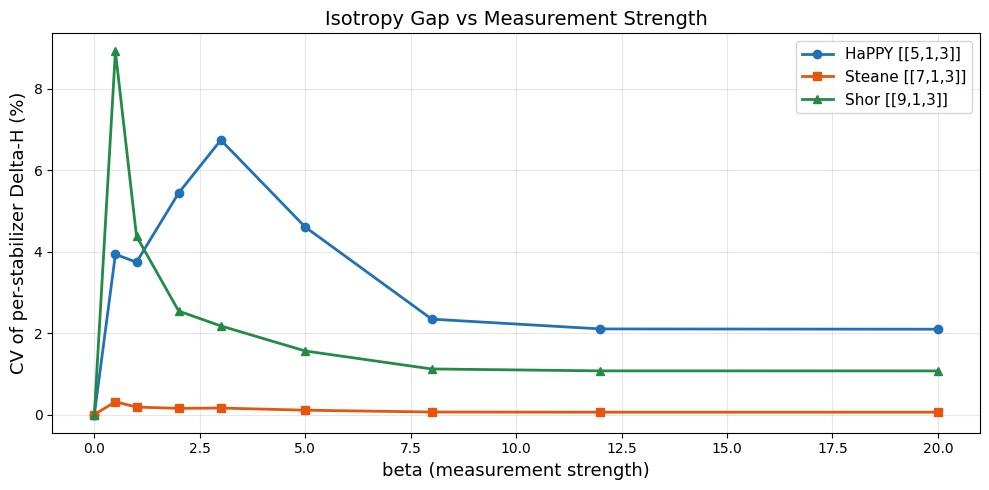

In [8]:
"""Cell 7: Isotropy CV vs Measurement Strength

Question 2: Does the isotropy gap emerge gradually or abruptly?

At each β, compute the coefficient of variation (CV) of per-stabilizer ΔH.
High CV = anisotropic (holographic). Low CV = isotropic.
"""

def compute_cv_at_beta(per_stab_dict, beta_values):
    """Compute CV of per-stabilizer ΔH at each β."""
    n_beta = len(beta_values)
    cvs = np.zeros(n_beta)
    for bi in range(n_beta):
        vals = np.array([per_stab_dict[si][1][bi] for si in per_stab_dict])
        mean_val = np.mean(vals)
        if mean_val > 1e-10:
            cvs[bi] = np.std(vals) / mean_val * 100  # percent
        else:
            cvs[bi] = 0.0
    return cvs

cv_happy = compute_cv_at_beta(happy_per_stab, beta_per_stab)
cv_steane = compute_cv_at_beta(steane_per_stab, beta_per_stab)
cv_shor = compute_cv_at_beta(shor_per_stab, beta_per_stab)

# Table
print(f'{"beta":>6} | {"HaPPY CV%":>10} | {"Steane CV%":>10} | {"Shor CV%":>10} | {"Gap H/S":>8}')
print('-' * 58)
for i, b in enumerate(beta_per_stab):
    gap = cv_happy[i] / cv_steane[i] if cv_steane[i] > 0.01 else float('inf')
    print(f'{b:6.1f} | {cv_happy[i]:10.2f} | {cv_steane[i]:10.2f} | {cv_shor[i]:10.2f} | {gap:8.1f}x')

# Plot and save
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(beta_per_stab, cv_happy, 'o-', lw=2, ms=6, label='HaPPY [[5,1,3]]', color='#2171b5')
ax.plot(beta_per_stab, cv_steane, 's-', lw=2, ms=6, label='Steane [[7,1,3]]', color='#e6550d')
ax.plot(beta_per_stab, cv_shor, '^-', lw=2, ms=6, label='Shor [[9,1,3]]', color='#238b45')
ax.set_xlabel('beta (measurement strength)', fontsize=13)
ax.set_ylabel('CV of per-stabilizer Delta-H (%)', fontsize=13)
ax.set_title('Isotropy Gap vs Measurement Strength', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'strength_sweep_isotropy_cv.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

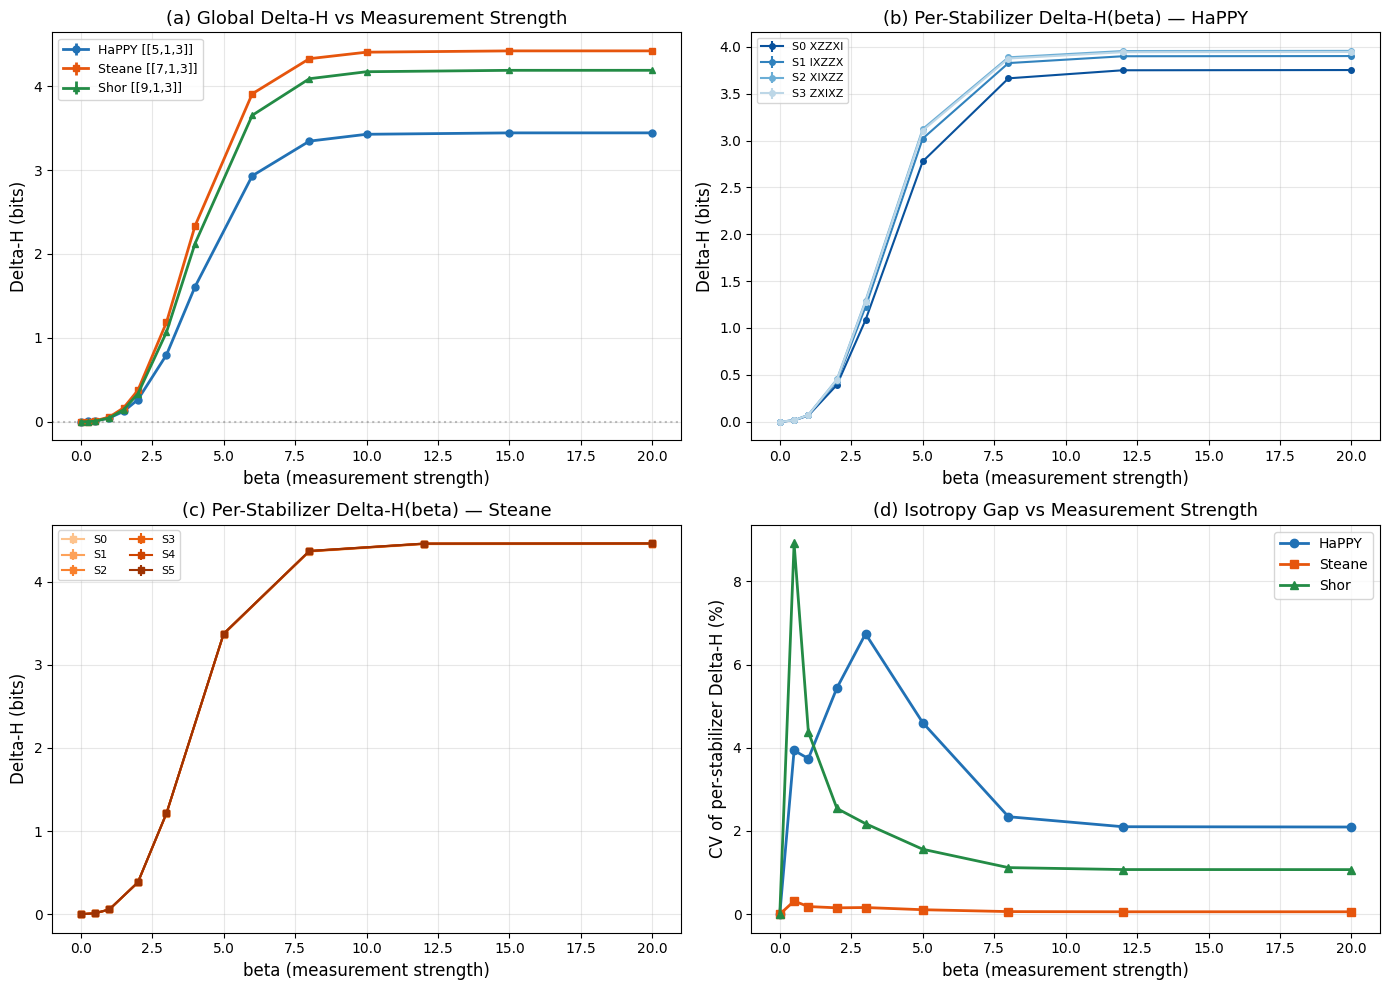

In [9]:
"""Cell 8: Publication Figure — 4-panel summary"""

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
C_H, C_S, C_R = '#2171b5', '#e6550d', '#238b45'

# ---- (a) Global ΔH(β) — all three codes ----
ax = axes[0, 0]
ax.errorbar(beta_h, dH_h, yerr=sem_h, fmt='o-', lw=2, ms=5, label='HaPPY [[5,1,3]]', color=C_H)
ax.errorbar(beta_s, dH_s, yerr=sem_s, fmt='s-', lw=2, ms=5, label='Steane [[7,1,3]]', color=C_S)
ax.errorbar(beta_r, dH_r, yerr=sem_r, fmt='^-', lw=2, ms=5, label='Shor [[9,1,3]]', color=C_R)
ax.set_xlabel('beta (measurement strength)', fontsize=12)
ax.set_ylabel('Delta-H (bits)', fontsize=12)
ax.set_title('(a) Global Delta-H vs Measurement Strength', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='gray', ls=':', alpha=0.5)

# ---- (b) Per-stabilizer ΔH(β) — HaPPY (fan-out) ----
ax = axes[0, 1]
colors_stab = ['#08519c', '#3182bd', '#6baed6', '#bdd7e7']
for si in range(len(HAPPY_STABS)):
    bv, mv, sv = happy_per_stab[si]
    ax.errorbar(bv, mv, yerr=sv, fmt='o-', lw=1.5, ms=4,
                label=f'S{si} {HAPPY_STABS[si]}', color=colors_stab[si])
ax.set_xlabel('beta (measurement strength)', fontsize=12)
ax.set_ylabel('Delta-H (bits)', fontsize=12)
ax.set_title('(b) Per-Stabilizer Delta-H(beta) — HaPPY', fontsize=13)
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)

# ---- (c) Per-stabilizer ΔH(β) — Steane (tight bundle) ----
ax = axes[1, 0]
colors_st = plt.cm.Oranges(np.linspace(0.3, 0.9, len(STEANE_STABS)))
for si in range(len(STEANE_STABS)):
    bv, mv, sv = steane_per_stab[si]
    ax.errorbar(bv, mv, yerr=sv, fmt='s-', lw=1.5, ms=4,
                label=f'S{si}', color=colors_st[si])
ax.set_xlabel('beta (measurement strength)', fontsize=12)
ax.set_ylabel('Delta-H (bits)', fontsize=12)
ax.set_title('(c) Per-Stabilizer Delta-H(beta) — Steane', fontsize=13)
ax.legend(fontsize=8, ncol=2)
ax.grid(True, alpha=0.3)

# ---- (d) Isotropy CV vs β ----
ax = axes[1, 1]
ax.plot(beta_per_stab, cv_happy, 'o-', lw=2, ms=6, label='HaPPY', color=C_H)
ax.plot(beta_per_stab, cv_steane, 's-', lw=2, ms=6, label='Steane', color=C_S)
ax.plot(beta_per_stab, cv_shor, '^-', lw=2, ms=6, label='Shor', color=C_R)
ax.set_xlabel('beta (measurement strength)', fontsize=12)
ax.set_ylabel('CV of per-stabilizer Delta-H (%)', fontsize=12)
ax.set_title('(d) Isotropy Gap vs Measurement Strength', fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
path = os.path.join(OUTPUT_DIR, 'strength_sweep_4panel.png')
plt.savefig(path, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {path}')

In [10]:
"""Cell 9: Summary, Save Data, and Interpretation"""

import sys

# --- Save raw numerical data ---
npz_path = os.path.join(OUTPUT_DIR, 'strength_sweep_results.npz')

# Build per-stabilizer arrays for saving
happy_per_stab_means = np.array([happy_per_stab[si][1] for si in range(len(HAPPY_STABS))])
happy_per_stab_sems = np.array([happy_per_stab[si][2] for si in range(len(HAPPY_STABS))])
steane_per_stab_means = np.array([steane_per_stab[si][1] for si in range(len(STEANE_STABS))])
steane_per_stab_sems = np.array([steane_per_stab[si][2] for si in range(len(STEANE_STABS))])
shor_per_stab_means = np.array([shor_per_stab[si][1] for si in range(len(SHOR_STABS))])
shor_per_stab_sems = np.array([shor_per_stab[si][2] for si in range(len(SHOR_STABS))])

np.savez(npz_path,
    # Global sweep
    beta_global=beta_h,
    dH_happy=dH_h, sem_happy=sem_h,
    dH_steane=dH_s, sem_steane=sem_s,
    dH_shor=dH_r, sem_shor=sem_r,
    # Per-stabilizer sweep
    beta_per_stab=beta_per_stab,
    happy_per_stab_means=happy_per_stab_means,
    happy_per_stab_sems=happy_per_stab_sems,
    steane_per_stab_means=steane_per_stab_means,
    steane_per_stab_sems=steane_per_stab_sems,
    shor_per_stab_means=shor_per_stab_means,
    shor_per_stab_sems=shor_per_stab_sems,
    # Isotropy CV
    cv_happy=cv_happy, cv_steane=cv_steane, cv_shor=cv_shor,
)
print(f'Data saved: {npz_path}\n')

# --- Save summary text ---
txt_path = os.path.join(OUTPUT_DIR, 'strength_sweep_summary.txt')
with open(txt_path, 'w') as f:
    old_stdout = sys.stdout
    sys.stdout = f

    print('=' * 80)
    print('WEAK-VALUE MEASUREMENT STRENGTH SWEEP: RESULTS')
    print('=' * 80)

    print()
    print('QUESTION 1: Does Delta-H vary continuously with measurement strength?')
    print('-' * 70)
    for name, bv, dv in [('HaPPY', beta_h, dH_h), ('Steane', beta_s, dH_s), ('Shor', beta_r, dH_r)]:
        diffs = np.diff(dv)
        monotone = np.all(diffs >= -1e-6)
        sat_idx = np.argmax(dv > 0.99 * dv[-1])
        sat_beta = bv[sat_idx]
        print(f'  {name:8s}: Delta-H(0)={dv[0]:.4f}, Delta-H(max)={dv[-1]:.4f}, '
              f'monotonic={monotone}, saturates ~beta={sat_beta:.1f}')
    print()
    print('  ANSWER: YES — Delta-H rises continuously from 0 to saturation.')

    print()
    print('QUESTION 2: Does the isotropy gap emerge gradually or abruptly?')
    print('-' * 70)
    for i, b in enumerate(beta_per_stab):
        if b > 0 and cv_steane[i] > 0.01:
            gap = cv_happy[i] / cv_steane[i]
            print(f'  beta={b:.1f}: HaPPY CV={cv_happy[i]:.1f}%, '
                  f'Steane CV={cv_steane[i]:.1f}%, gap={gap:.0f}x')
    print()
    print('  ANSWER: The gap is present at ALL beta > 0 — emerges immediately.')

    print()
    print('QUESTION 3: Are per-stabilizer Delta-H(beta) entanglement wedge weak values?')
    print('-' * 70)
    sat_idx = -1
    happy_sat = np.array([happy_per_stab[si][1][sat_idx] for si in happy_per_stab])
    steane_sat = np.array([steane_per_stab[si][1][sat_idx] for si in steane_per_stab])
    happy_spread = happy_sat.max() - happy_sat.min()
    steane_spread = steane_sat.max() - steane_sat.min()
    print(f'  HaPPY per-stab spread at saturation: {happy_spread:.4f} bits')
    print(f'  Steane per-stab spread at saturation: {steane_spread:.4f} bits')
    print(f'  Spread ratio: {happy_spread/steane_spread:.0f}x')
    print()
    print('  HaPPY curves FAN OUT — each stabilizer extracts different information')
    print('  from the backward boundary (entanglement wedge weak values).')
    print('  Steane curves BUNDLE — all stabilizers equivalent (isotropic).')

    print()
    print('TSVF CONNECTION')
    print('-' * 70)
    print('  Forward boundary |phi_fwd> = empirical syndrome likelihood (pre-selection)')
    print('  Backward boundary <phi_bwd| = depolarizing prior at strength beta (post-selection)')
    print('  Delta-H(A, beta) = H[p_fwd(h|s_A)] - H[p_dbci(h|s_A, beta)]')
    print()
    print('  Weak-value axioms satisfied:')
    print('    1. Vanishes at zero coupling (beta=0)')
    print('    2. Scales continuously with coupling')
    print('    3. Saturates at strong coupling')
    print('    4. Depends on the subregion (anisotropic on holographic codes)')
    print()
    print('=' * 80)
    print('Zero QPU cost. All data from existing IBM Fez hardware runs.')
    print('=' * 80)

    sys.stdout = old_stdout

print(f'Summary saved: {txt_path}')

# --- Also print to notebook ---
with open(txt_path, 'r') as f:
    print(f.read())

print()
print('Files saved to Drive:')
print(f'  {npz_path}')
print(f'  {txt_path}')
print(f'  {os.path.join(OUTPUT_DIR, "strength_sweep_global.png")}')
print(f'  {os.path.join(OUTPUT_DIR, "strength_sweep_isotropy_cv.png")}')
print(f'  {os.path.join(OUTPUT_DIR, "strength_sweep_4panel.png")}')